# DATA CLEANING

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


sdkC = pd.read_csv("3SudokuCombined.csv")

print(sdkC)

      Class Before1     Type Correct  Time1 Mins Seconds Time2  Before2  \
0         1     Yes  Numbers      No    NaN  NaN     NaN   NaN      NaN   
1         1     Yes    Greek      No  10:12   10      12   612      NaN   
2         1     Yes    Greek      No  04:12    4      12   252      NaN   
3         1      No  Letters      No  08:35    8      35   515      NaN   
4         1      No  Letters      No  01:28    1      28    88      NaN   
...     ...     ...      ...     ...    ...  ...     ...   ...      ...   
1693      8     NaN   Letter     Yes    NaN    3      30   210   Inside   
1694      8     NaN   Letter      No    NaN    3      26   206  Outside   
1695      8     NaN   Number     Yes    NaN    2      43   163  Outside   
1696      8     NaN   Number     Yes    NaN    2      20   140  Outside   
1697      8     NaN   Letter     Yes    NaN    1      27    87  Outside   

            Logic  
0             NaN  
1             NaN  
2             NaN  
3             NaN  

## CATEGORICAL AND DISCRETE NUMERICAL VARIABLES


In [5]:
freq_table = pd.crosstab(sdkC["Before1"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Before1,,
No,150,0.088339
Yes,437,0.257362
NaN,1111,0.654299


 It is evident that the variable Before1 contains a disproportionate number of missing values (1,111 out of 1,698 observations). Due to this high sparsity, the variable lacks sufficient predictive power and will be excluded from the primary analysis to maintain the integrity of the study.Furthermore, the Before2 variable already encompasses the information contained within Before1. Given this redundancy and the high proportion of missing values in the latter , Before1 provides negligible marginal utility and will be excluded from the final dataset to streamline the analysis

In [6]:
freq_table = pd.crosstab(sdkC["Before2"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Before2,,
.,5,0.002945
Inside,216,0.127208
No,238,0.140165
Out_3,162,0.095406
Outside,353,0.207892
Within_3,132,0.077739
NaN,592,0.348645


 We can notice that there is two different way to express missing element "." and "NaN" :

In [7]:
import numpy as np 


valid_codes=["No","Inside","Outside","Out_3","Within_3"]

for i in range(0, len(sdkC)):
    if sdkC.loc[i,"Before2"] not in valid_codes:
        sdkC.loc[i,"Before2"]=np.nan
pd.crosstab(sdkC["Before2"], "count",dropna=False)

col_0,count
Before2,
Inside,216
No,238
Out_3,162
Outside,353
Within_3,132
NaN,597


In [8]:
freq_table = pd.crosstab(sdkC["Type"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Type,,
Greek,413,0.243227
Letter,127,0.074794
Letters,312,0.183746
Number,82,0.048292
Numbers,317,0.186690
Symbol,135,0.079505
Symbols,312,0.183746


In [9]:
freq_table = pd.crosstab(sdkC["Class"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Class,,
1,169,0.099529
2,257,0.151355
3,162,0.095406
4,278,0.163722
5,108,0.063604
6,276,0.162544
7,130,0.076561
8,318,0.187279


In [10]:
freq_table = pd.crosstab(sdkC["Logic"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Logic,,
.,5,0.002945
Indifferent,308,0.181390
No,111,0.065371
Yes,682,0.401649
NaN,592,0.348645


In [11]:
import numpy as np 


valid_codes=["No","Yes","Indifferent"]

for i in range(0, len(sdkC)):
    if sdkC.loc[i,"Logic"] not in valid_codes:
        sdkC.loc[i,"Logic"]=np.nan
pd.crosstab(sdkC["Logic"], "count",dropna=False)

col_0,count
Logic,
Indifferent,308
No,111
Yes,682
NaN,597


## CORRECTION  OF CATEGORICAL AND DESCRIPTIVE NUMERICAL VARIABLES ERRORS

In [12]:
#Before2

sdkC["Before2"]=sdkC["Before2"].replace({"Inside":"Within_3", "Outside": "Out_3", "No": "No"})

freq_table = pd.crosstab(sdkC["Before2"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Before2,,
No,238,0.140165
Out_3,515,0.303298
Within_3,348,0.204947
NaN,597,0.351590


In [13]:
#Type

sdkC["Type"]= sdkC["Type"].replace({"Symbol":"Symbols", "Letter": "Letters", "Number": "Numbers"})

freq_table = pd.crosstab(sdkC["Type"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Type,,
Greek,413,0.243227
Letters,439,0.258539
Numbers,399,0.234982
Symbols,447,0.263251


In [14]:
#Logic
freq_table = pd.crosstab(sdkC["Logic"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Logic,,
Indifferent,308,0.181390
No,111,0.065371
Yes,682,0.401649
NaN,597,0.351590


In [15]:
#Class

sdkC["Class"]=sdkC["Class"]

freq_table = pd.crosstab(sdkC["Class"],"count",dropna=False)
freq_table["proportion"] = freq_table["count"]/len(sdkC)
freq_table

col_0,count,proportion
Class,,
1,169,0.099529
2,257,0.151355
3,162,0.095406
4,278,0.163722
5,108,0.063604
6,276,0.162544
7,130,0.076561
8,318,0.187279


## CONTINUOUS VARIABLE

The variables Time1, Time2, Mins, and Seconds are redundant as they all measure the same outcome. We have selected TIME2 (total seconds) as our primary metric due to its format being better suited for statistical modeling. Consequently, the remaining time-related features will be dropped to simplify the final feature set.

In [16]:
print(sdkC['Time2'].dropna().describe())

count     1611
unique     426
top        160
freq        14
Name: Time2, dtype: object


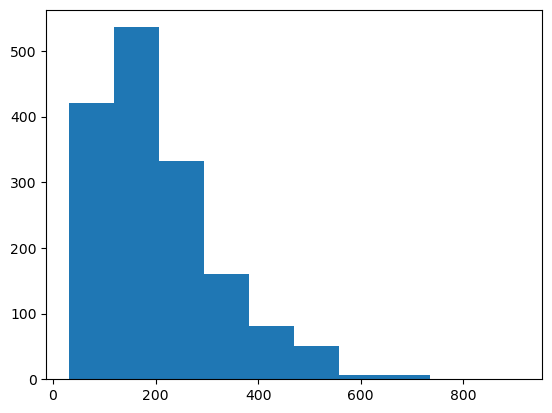

In [17]:
sdkC["Time2"]= pd.to_numeric(sdkC["Time2"], errors='coerce')
plt.hist(sdkC["Time2"].dropna())
plt.show()

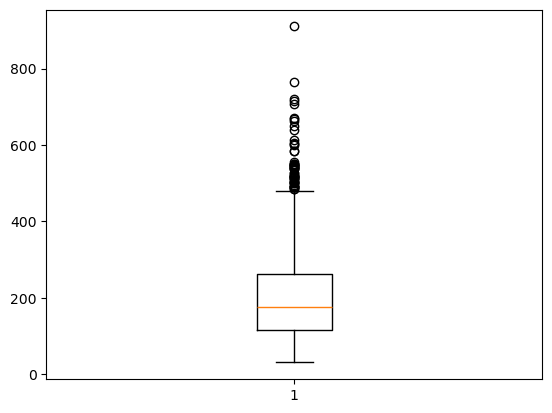

In [18]:
plt.boxplot(sdkC["Time2"].dropna())
plt.show()

In this context, values outside the range "[5,420]" are deemed anomalous and should be changed to "NaN".

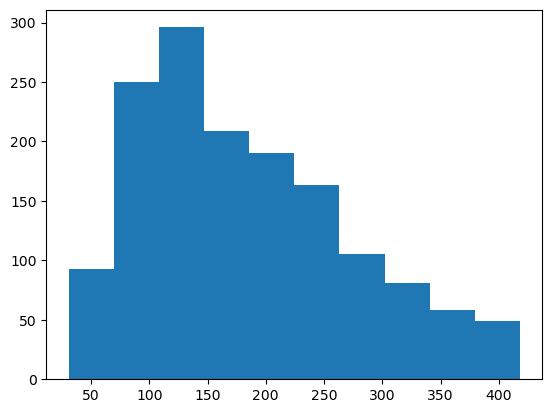

In [19]:
for i in range(0, len(sdkC)):
    if not 5 < sdkC.loc[i,"Time2"] < 420:
        sdkC.loc[i,"Time2"] = np.nan
plt.hist(sdkC["Time2"].dropna())
plt.show()

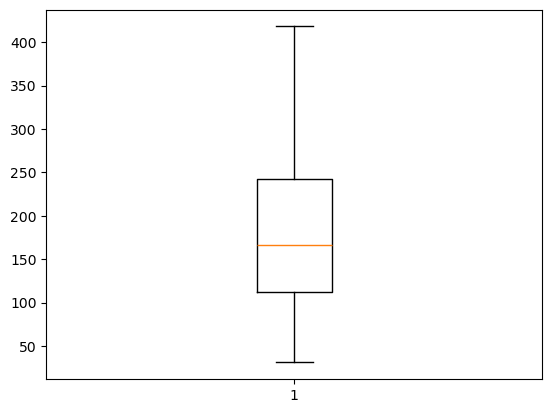

In [20]:
plt.boxplot(sdkC["Time2"].dropna())
plt.show()

THE FINAL DATASET

In [21]:
sdkC=sdkC[['Before2', 'Type', 'Logic', 'Class', 'Time2', 'Correct']].copy()
sdkC=sdkC.rename(columns={'Before2': 'Before',"Time2":"Time"})
sdkC

,Before,Type,Logic,Class,Time,Correct
0,NaN,Numbers,NaN,1,NaN,No
1,NaN,Greek,NaN,1,NaN,No
2,NaN,Greek,NaN,1,252.0,No
3,NaN,Letters,NaN,1,NaN,No
4,NaN,Letters,NaN,1,88.0,No
...,...,...,...,...,...,...
1693,Within_3,Letters,Indifferent,8,210.0,Yes
1694,Out_3,Letters,Yes,8,206.0,No
1695,Out_3,Numbers,Yes,8,163.0,Yes
1696,Out_3,Numbers,Yes,8,140.0,Yes


In [22]:

sdkC.to_csv('3SudokuCombined_cleaned.csv', index=False)